### Initial Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### Load data

In [11]:
df = pd.read_csv("../data/games_march2025_cleaned.csv")
df.shape

(89618, 47)

### Drop Irrelevant Columns

In [12]:
drop_cols = ["header_image", "website", "support_url", "support_email","metacritic_url", "screenshots", "movies", "packages",
    "detailed_description", "about_the_game", "short_description","notes", "user_score", "score_rank",]

df_clean = df.drop(columns=drop_cols)
df_clean.shape

(89618, 33)

### Parse Genre Columns

In [13]:
import ast

def parse_list_col(x):
    try:
        return ast.literal_eval(x) if pd.notna(x) else []
    except (ValueError, SyntaxError):
        return []

df_clean["genres"] = df_clean["genres"].apply(parse_list_col)
df_clean["n_genres"] = df_clean["genres"].apply(len)

### Filtering

In [14]:
MIN_REVIEWS = 30
MIN_GAMES_PER_GENRE = 100

df_reviewed = df_clean[df_clean["num_reviews_total"] >= MIN_REVIEWS].copy()
print(f"Games kept: {len(df_reviewed)} / {len(df_clean)} ({len(df_reviewed)/len(df_clean)*100:.1f}%)")

Games kept: 34583 / 89618 (38.6%)


### Derive primary_genre

In [15]:
NON_GENRE_DESCRIPTORS = {"Violent", "Gore", "Nudity", "Sexual Content", "Free To Play", "Early Access"}

def get_primary_genre(genre_list):
    cleaned = [g for g in genre_list if g not in NON_GENRE_DESCRIPTORS]
    return cleaned[0] if cleaned else np.nan

df_reviewed["primary_genre"] = df_reviewed["genres"].apply(get_primary_genre)
n_no_genre = df_reviewed["primary_genre"].isna().sum()
print(f"Games with no usable genre: {n_no_genre}")

df_model = df_reviewed.dropna(subset=["primary_genre"]).copy()

genre_counts = df_model["primary_genre"].value_counts()
eligible_genres = genre_counts[genre_counts >= MIN_GAMES_PER_GENRE].index
df_model = df_model[df_model["primary_genre"].isin(eligible_genres)].copy()

print(f"Genres retained: {len(eligible_genres)}")
print(f"Final sample size: {len(df_model)}")

Games with no usable genre: 167
Genres retained: 9
Final sample size: 34336


### Prepare Response Variable

In [16]:
n_boundary = ((df_model["pct_pos_total"] == 0) | (df_model["pct_pos_total"] == 100)).sum()
print(f"Games at exact 0% or 100% positive: {n_boundary}")

eps = 1e-4
p = (df_model["pct_pos_total"] / 100).clip(eps, 1 - eps)
df_model["logit_pct_pos"] = np.log(p / (1 - p))

df_model["logit_pct_pos"].describe()

Games at exact 0% or 100% positive: 396


count    34336.000000
mean         1.605447
std          1.303999
min         -4.595120
25%          0.847298
50%          1.516347
75%          2.197225
max          9.210240
Name: logit_pct_pos, dtype: float64

###  Model Skeleton

In [17]:
model = smf.ols("logit_pct_pos ~ C(primary_genre) + price + C(required_age)", data=df_model).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          logit_pct_pos   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     28.88
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          1.36e-108
Time:                        19:37:48   Log-Likelihood:                -57548.
No. Observations:               34336   AIC:                         1.151e+05
Df Residuals:                   34315   BIC:                         1.153e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     1.7292      1.294      1.336      0.182      -0.807       4.266
C(primary_genre)[T.Adventure]                 0.2610      0.018     14.528      0.000       0.226       0.296
C(primary_genre)[T.Casual]                    0.2889      0.021     14.070      0.000       0.249       0.329
C(primary_genre)[T.Indie]                     0.0846      0.024      3.524      0.000       0.038       0.132
C(primary_genre)[T.Massively Multiplayer]    -0.8454      0.102     -8.329      0.000      -1.044      -0.646
C(primary_genre)[T.RPG]                      -0.0173      0.050     -0.346      0.729      -0.115       0.080
C(primary_genre)[T.Racing]                   -0.0943      0.087     -1.080      0.280      -0.265       0.077
C(primary_genre)[T.Simulation]               -0.3352      0.043     -7.756      0.000      -0.420      -0.250
C(primary_genre)[T.Strategy]                 -0.1449      0.056     -2.573      0.010      -0.255      -0.035
C(required_age)[T.0]                         -0.2488      1.294     -0.192      0.848      -2.785       2.288
C(required_age)[T.1]                          0.2833      1.830      0.155      0.877      -3.303       3.870
C(required_age)[T.6]                         -0.7740      1.494     -0.518      0.605      -3.703       2.155
C(required_age)[T.7]                         -2.0467      1.830     -1.119      0.263      -5.633       1.540
C(required_age)[T.10]                        -0.6407      1.334     -0.480      0.631      -3.255       1.973
C(required_age)[T.12]                        -0.3325      1.372     -0.242      0.809      -3.023       2.358
C(required_age)[T.13]                        -0.3425      1.300     -0.264      0.792      -2.890       2.205
C(required_age)[T.15]                         0.0727      1.830      0.040      0.968      -3.514       3.659
C(required_age)[T.16]                        -0.1391      1.321     -0.105      0.916      -2.727       2.449
C(required_age)[T.17]                        -0.4331      1.295     -0.334      0.738      -2.971       2.105
C(required_age)[T.18]                        -0.5481      1.301     -0.421      0.674      -3.099       2.003
price                                         0.0029      0.001      4.118      0.000       0.002       0.004
==============================================================================
Omnibus:                    17800.183   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           221221.242
Skew:                           2.212   Prob(JB):                         0.00
Kurtosis:                      14.622   Cond. No.                     8.95e+03
================================================

### Check Assumptions

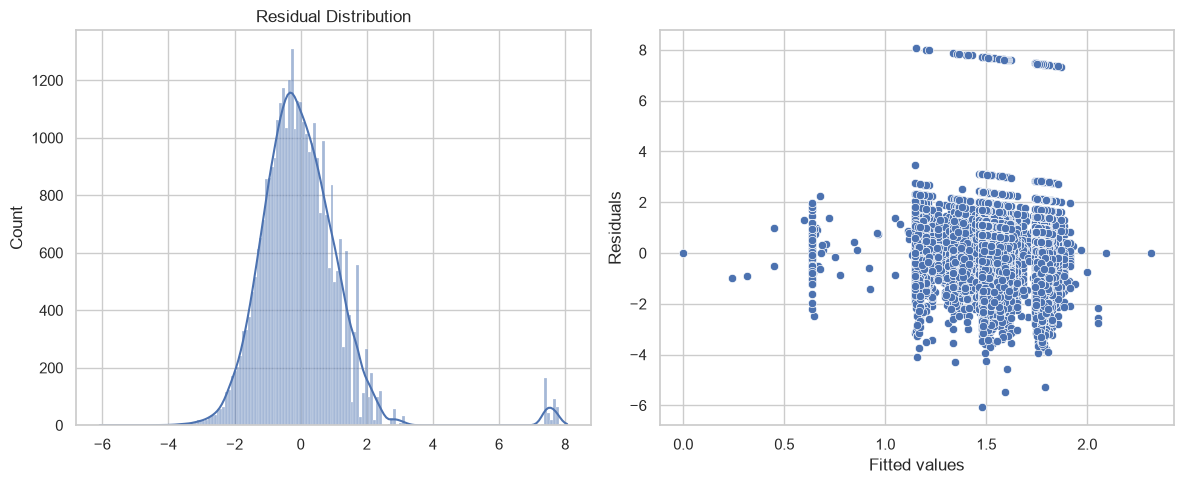

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title("Residual Distribution")

sns.scatterplot(x=model.fittedvalues.values, y=model.resid.values, ax=axes[1])
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [19]:
pd.crosstab(df_model["primary_genre"], df_model["required_age"])

required_age,-1,0,1,6,7,10,12,13,15,16,17,18
primary_genre,,,,,,,,,,,,
Action,1,13402,0,1,0,6,5,56,0,15,416,51
Adventure,0,8205,1,1,0,3,2,14,0,4,78,16
Casual,0,5727,0,0,1,0,1,2,1,0,7,9
Indie,0,3664,0,0,0,0,0,6,0,1,7,7
Massively Multiplayer,0,160,0,0,0,2,0,1,0,0,2,0
RPG,0,660,0,0,0,3,0,23,0,2,29,1
Racing,0,223,0,1,0,0,0,0,0,0,0,0
Simulation,0,959,0,0,0,1,0,4,0,1,2,2
Strategy,0,534,0,0,0,1,0,4,0,1,10,0


In [20]:
df_model["age_restricted"] = (df_model["required_age"] > 0).astype(int)
model2 = smf.ols("logit_pct_pos ~ C(primary_genre) + price + age_restricted", data=df_model).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          logit_pct_pos   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     57.26
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          1.29e-115
Time:                        19:43:15   Log-Likelihood:                -57550.
No. Observations:               34336   AIC:                         1.151e+05
Df Residuals:                   34325   BIC:                         1.152e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     1.4804      0.013    115.744      0.000       1.455       1.505
C(primary_genre)[T.Adventure]                 0.2610      0.018     14.530      0.000       0.226       0.296
C(primary_genre)[T.Casual]                    0.2885      0.021     14.057      0.000       0.248       0.329
C(primary_genre)[T.Indie]                     0.0846      0.024      3.523      0.000       0.038       0.132
C(primary_genre)[T.Massively Multiplayer]    -0.8475      0.101     -8.356      0.000      -1.046      -0.649
C(primary_genre)[T.RPG]                      -0.0150      0.050     -0.301      0.763      -0.112       0.083
C(primary_genre)[T.Racing]                   -0.0959      0.087     -1.100      0.271      -0.267       0.075
C(primary_genre)[T.Simulation]               -0.3351      0.043     -7.756      0.000      -0.420      -0.250
C(primary_genre)[T.Strategy]                 -0.1443      0.056     -2.562      0.010      -0.255      -0.034
price                                         0.0029      0.001      4.130      0.000       0.002       0.004
age_restricted                               -0.1805      0.047     -3.819      0.000      -0.273      -0.088
==============================================================================
Omnibus:                    17795.980   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           221088.647
Skew:                           2.211   Prob(JB):                         0.00
Kurtosis:                      14.618   Cond. No.                         200.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""